In [1]:
import os
import numpy as np
import json
import matplotlib.pyplot as plt
import json
import pandas as pd
from PLS import PLS

neurons = 'closest'

In [2]:
if neurons == 'closest':
    path = r'closest_neurons.xlsx'
if neurons == 'furthest':
    path = r'furthest_neurons.xlsx'
top_neurons = pd.read_excel(path)
top_neurons = top_neurons.dropna(subset=['recording', 'unit'])
print(f'Found {len(top_neurons)} neurons.')

Found 45 neurons.


In [3]:
PLS_TESTING_STIM = ["exp1_ZF A_20db_180ms_8b_1xomit_8b_silence",]
PLS_TRAINING_STIM = ["exp1_ZF A_20db_180ms_8b_1xomit_8b_silence",]
DB_PATH = r"C:\\Users\\tmerri03\\Desktop\\Temp Neural Files\\awake_recordings.db"
STIM_LIB_PATH = r"R:\\Data\\tyler\\Recordings\\Stim\\Stimuli Library"
RECORDINGS_PATH = r"R:\\Data\\RhythmPerception\\Neural Recordings\\Recordings"

pls = PLS(
    DB_PATH=r"C:\\Users\\tmerri03\\Desktop\\Temp Neural Files\\awake_recordings.db",
    RECORDINGS_PATH=r"R:\\Data\\RhythmPerception\\Neural Recordings\\Recordings",
    STIM_LIB_PATH = r"R:\\Data\\tyler\\Recordings\\Stim\\Stimuli Library",
    REGION='Field L',
    PLS_TESTING_STIM=PLS_TESTING_STIM,
    PLS_TRAINING_STIM=PLS_TRAINING_STIM,
    save_dir=fr'C:\Users\tmerri03\Desktop\PLS Results\template\{neurons}'
)

In [ ]:
pls.prepare(top_neurons)

In [5]:
pls.fit()

 --- Training Inputs: --- 
    | Neurons: 32
    | X Shape: (1260, 480)
    | Y Shape: (1260, 2)
    └→ Training Partial Least Squares Regression Model...



In [6]:
stim = {'180 Regular': 'exp1_ZF A_20db_180ms_8b_1xomit_8b_silence'}
Z_omit_A_180_reg, Y_omit_A_180_reg, T_omit_A_180_reg = pls.trajectory(top_neurons, stim['180 Regular'])
trajectories = {'180 Regular': Z_omit_A_180_reg}
T = {'180 Regular': T_omit_A_180_reg}
colors = {'180 Regular': '#a1d99b'}

--- Generating exp1_ZF A_20db_180ms_8b_1xomit_8b_silence PLS Response Matrices for Field L ---

    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    exp1_ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
    ZF A_20db_180ms_8b_1xomit_8b_silence
Error in baseline calculation. List sizes dont match. Skipping.
    exp1_ZF A_20db_180ms_8b_1xomit_8b_silence
Error in baseline calculation. List sizes dont match. Skipping.
    exp1_ZF A_20db_180ms_8b_1xomit_8b_silence
Error in baseline calculation. List sizes dont match. Skipping.
Error in baseline calculation. List sizes dont match. Skipping.
    exp1_ZF A_20db

In [7]:
beat_times = {}
def get_onsets_tempo_omission(filepath):
    """
    Parse beat onset times, tempo, omission location, and beat duration.

    Parameters
    ----------
    filepath : str
        Path to the stimulus metadata/log file.

    Returns
    -------
    onset_times : list of float
        Expected onset times of all beats, including omitted beats.

    tempo : float
        IOI in seconds.

    omission_idx : int
        0-based index of the omitted beat.

    omission_time : float
        Expected onset time of the omitted beat in seconds.

    beat_duration : float
        Duration of the beat sound in seconds.

    sample_rate : int
        Sample rate of the beat WAV file.
    """
    import re
    import numpy as np
    from scipy.io import wavfile
    with open(filepath, "r") as f:
        text = f.read()

    # -------------------------
    # Tempo
    # -------------------------
    tempo_match = re.search(
        r"(?:Target\s+)?Tempo \(IOI\):\s*([\d.]+)\s*s",
        text,
        re.IGNORECASE
    )

    if tempo_match is None:
        tempo=None
    else:
        tempo = float(tempo_match.group(1))

    # -------------------------
    # Beat sound path
    # -------------------------
    sound_match = re.search(
        r"Beat sound:\s*(.+)",
        text
    )

    if sound_match is None:
        raise ValueError("Could not find Beat sound path.")

    sound_path = sound_match.group(1).strip()

    # -------------------------
    # Read beat WAV
    # -------------------------
    sample_rate, sound = wavfile.read(sound_path)

    # Convert stereo to mono if necessary
    if sound.ndim > 1:
        sound = sound.mean(axis=1)

    # -------------------------
    # Determine sound duration
    # -------------------------
    # Use a threshold relative to the maximum amplitude.
    amplitude = np.abs(sound.astype(float))
    threshold = 0.01 * amplitude.max()

    active = np.where(amplitude > threshold)[0]

    if len(active) == 0:
        raise ValueError("Could not detect sound in beat WAV.")

    first_sample = active[0]
    last_sample = active[-1]

    beat_duration = (last_sample - first_sample + 1) / sample_rate

    # -------------------------
    # Beat onset times
    # -------------------------
    onset_times = []
    omission_idx = None

    for line in text.splitlines():

        match = re.match(
            r"^\s*(pre|omitted|post)\s+\d+\s+\d+\s+([\d.]+)",
            line
        )

        if match:
            segment = match.group(1)
            onset = float(match.group(2))

            if segment == "omitted":
                omission_idx = len(onset_times)

            onset_times.append(onset)

    if not onset_times:
        raise ValueError("No beat onset times found.")

    if omission_idx is None:
        raise ValueError("No omitted beat found.")

    omission_time = onset_times[omission_idx]

    return (
        onset_times,
        tempo,
        omission_idx,
        omission_time,
        beat_duration,
        sample_rate,
    )
base_fp = r'C:\Users\tmerri03\Desktop\RhythmStimuli\Tempi Range Stimuli 8-25-26\Stim Files\File Data'
for key in stim.keys():
    if key == 'Single Beat':
        onset_times = [0.518594]
        tempo = 0.180
    else:
        onset_times, tempo, omission_location, omission_time, beat_duration, sr = get_onsets_tempo_omission(os.path.join(base_fp, f'{stim[key]}_onsets.txt'))
        beats = np.array(onset_times) - np.array(onset_times)[0]

    for i in range(0,2):
        beats = np.append(beats, beats[-1]+0.100)
    beat_times[key] = beats

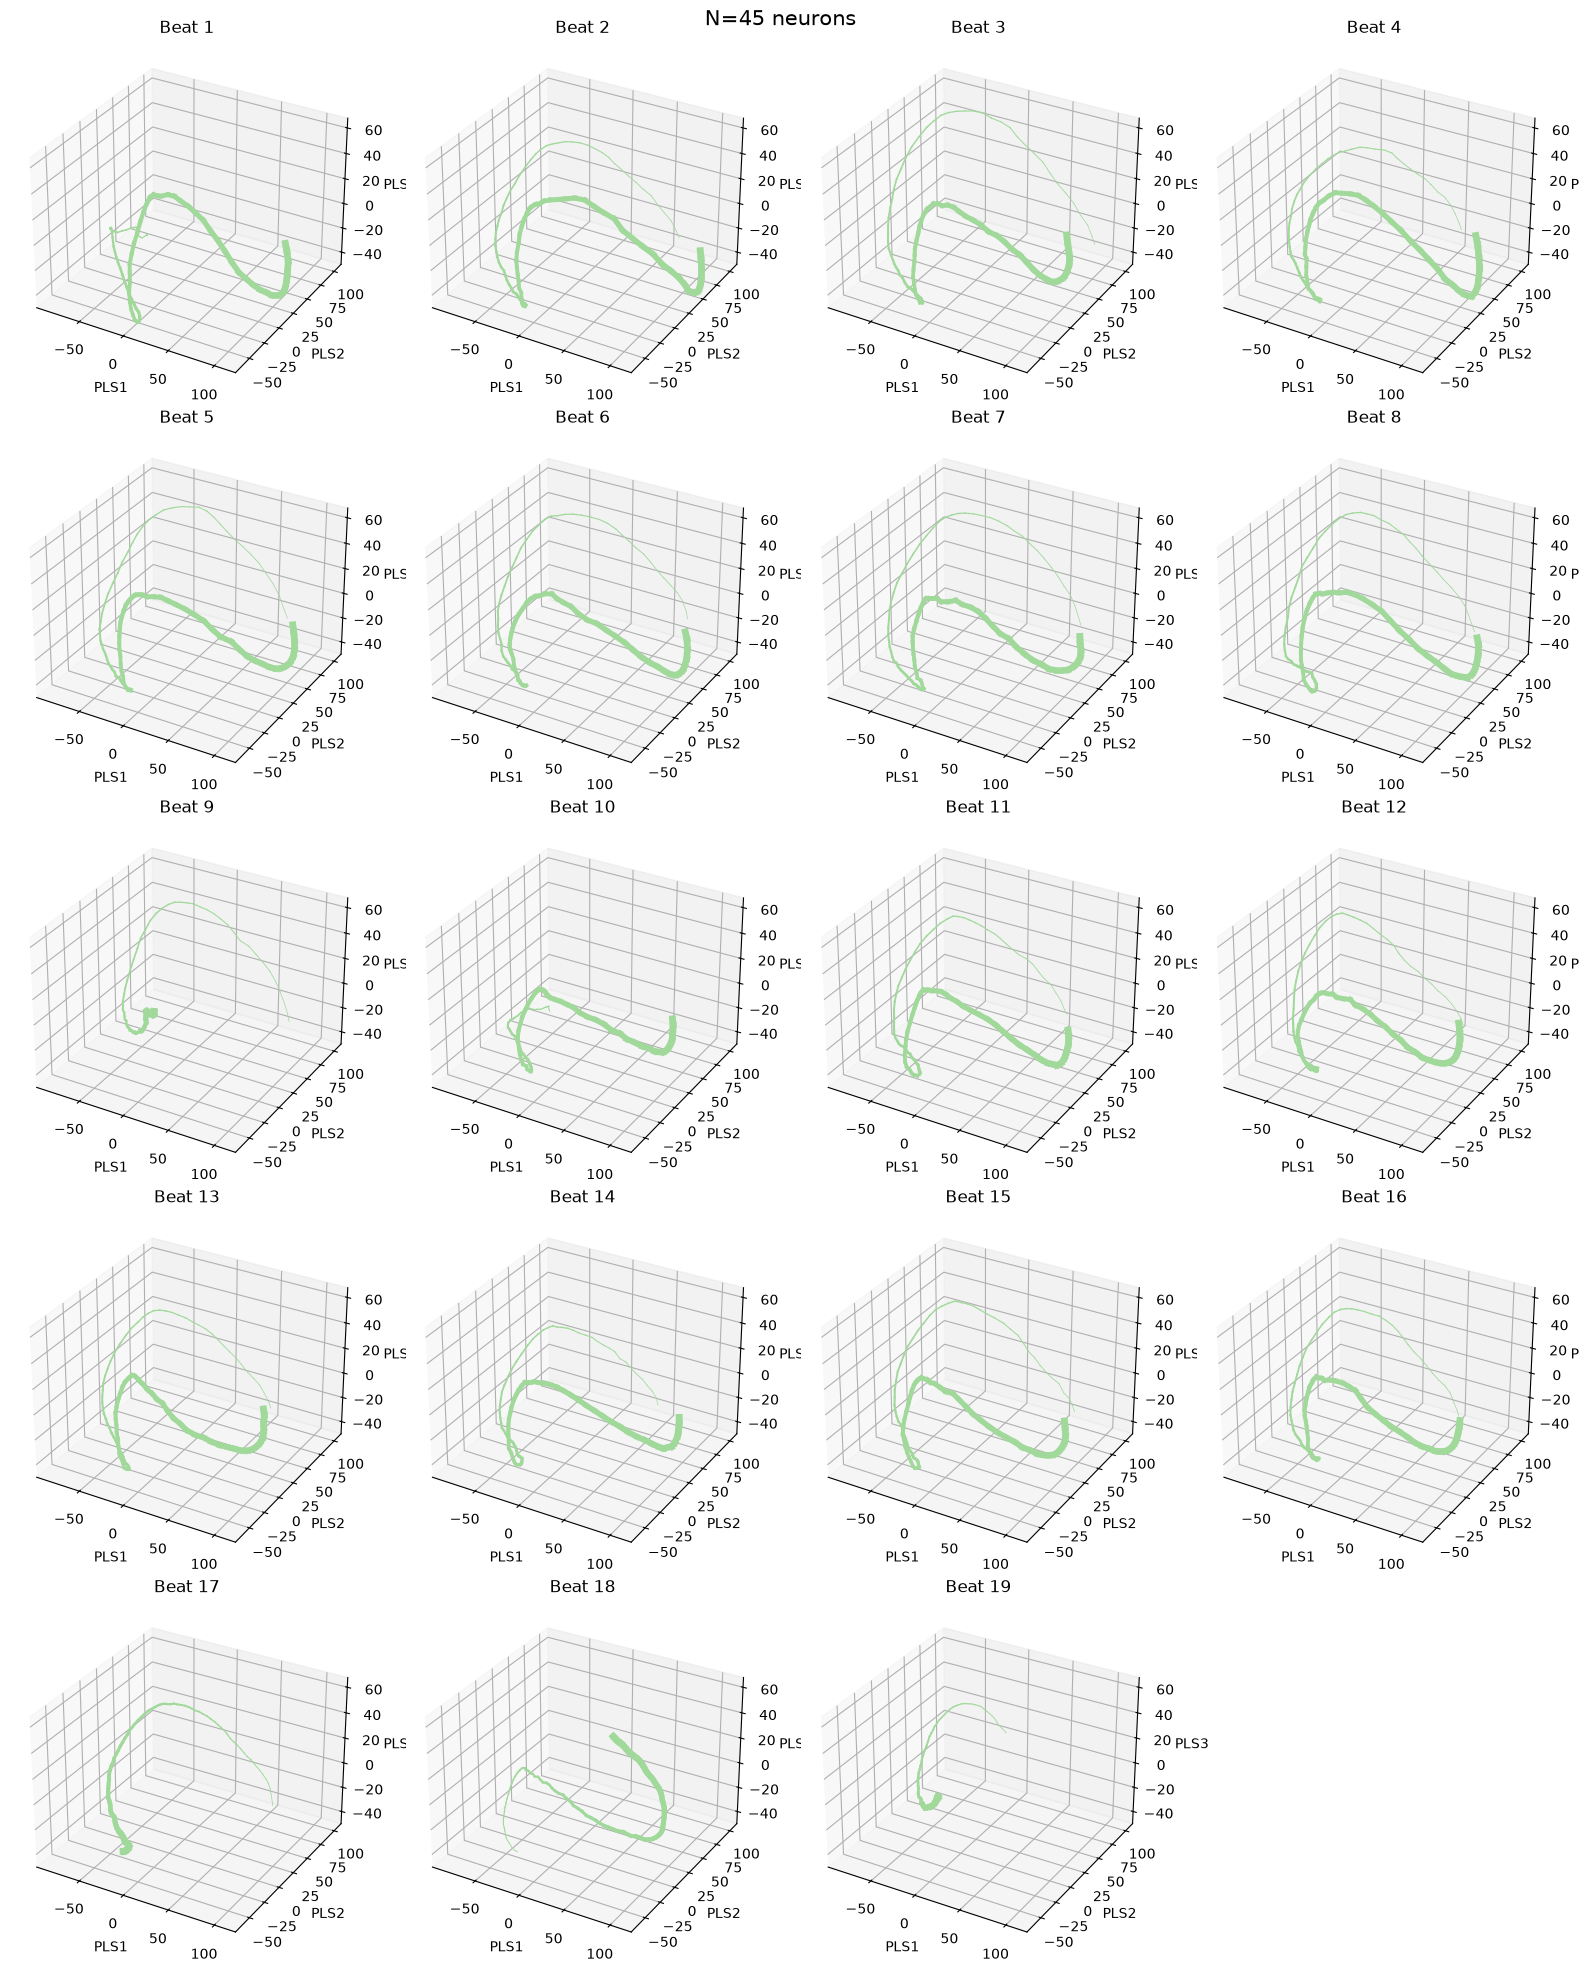

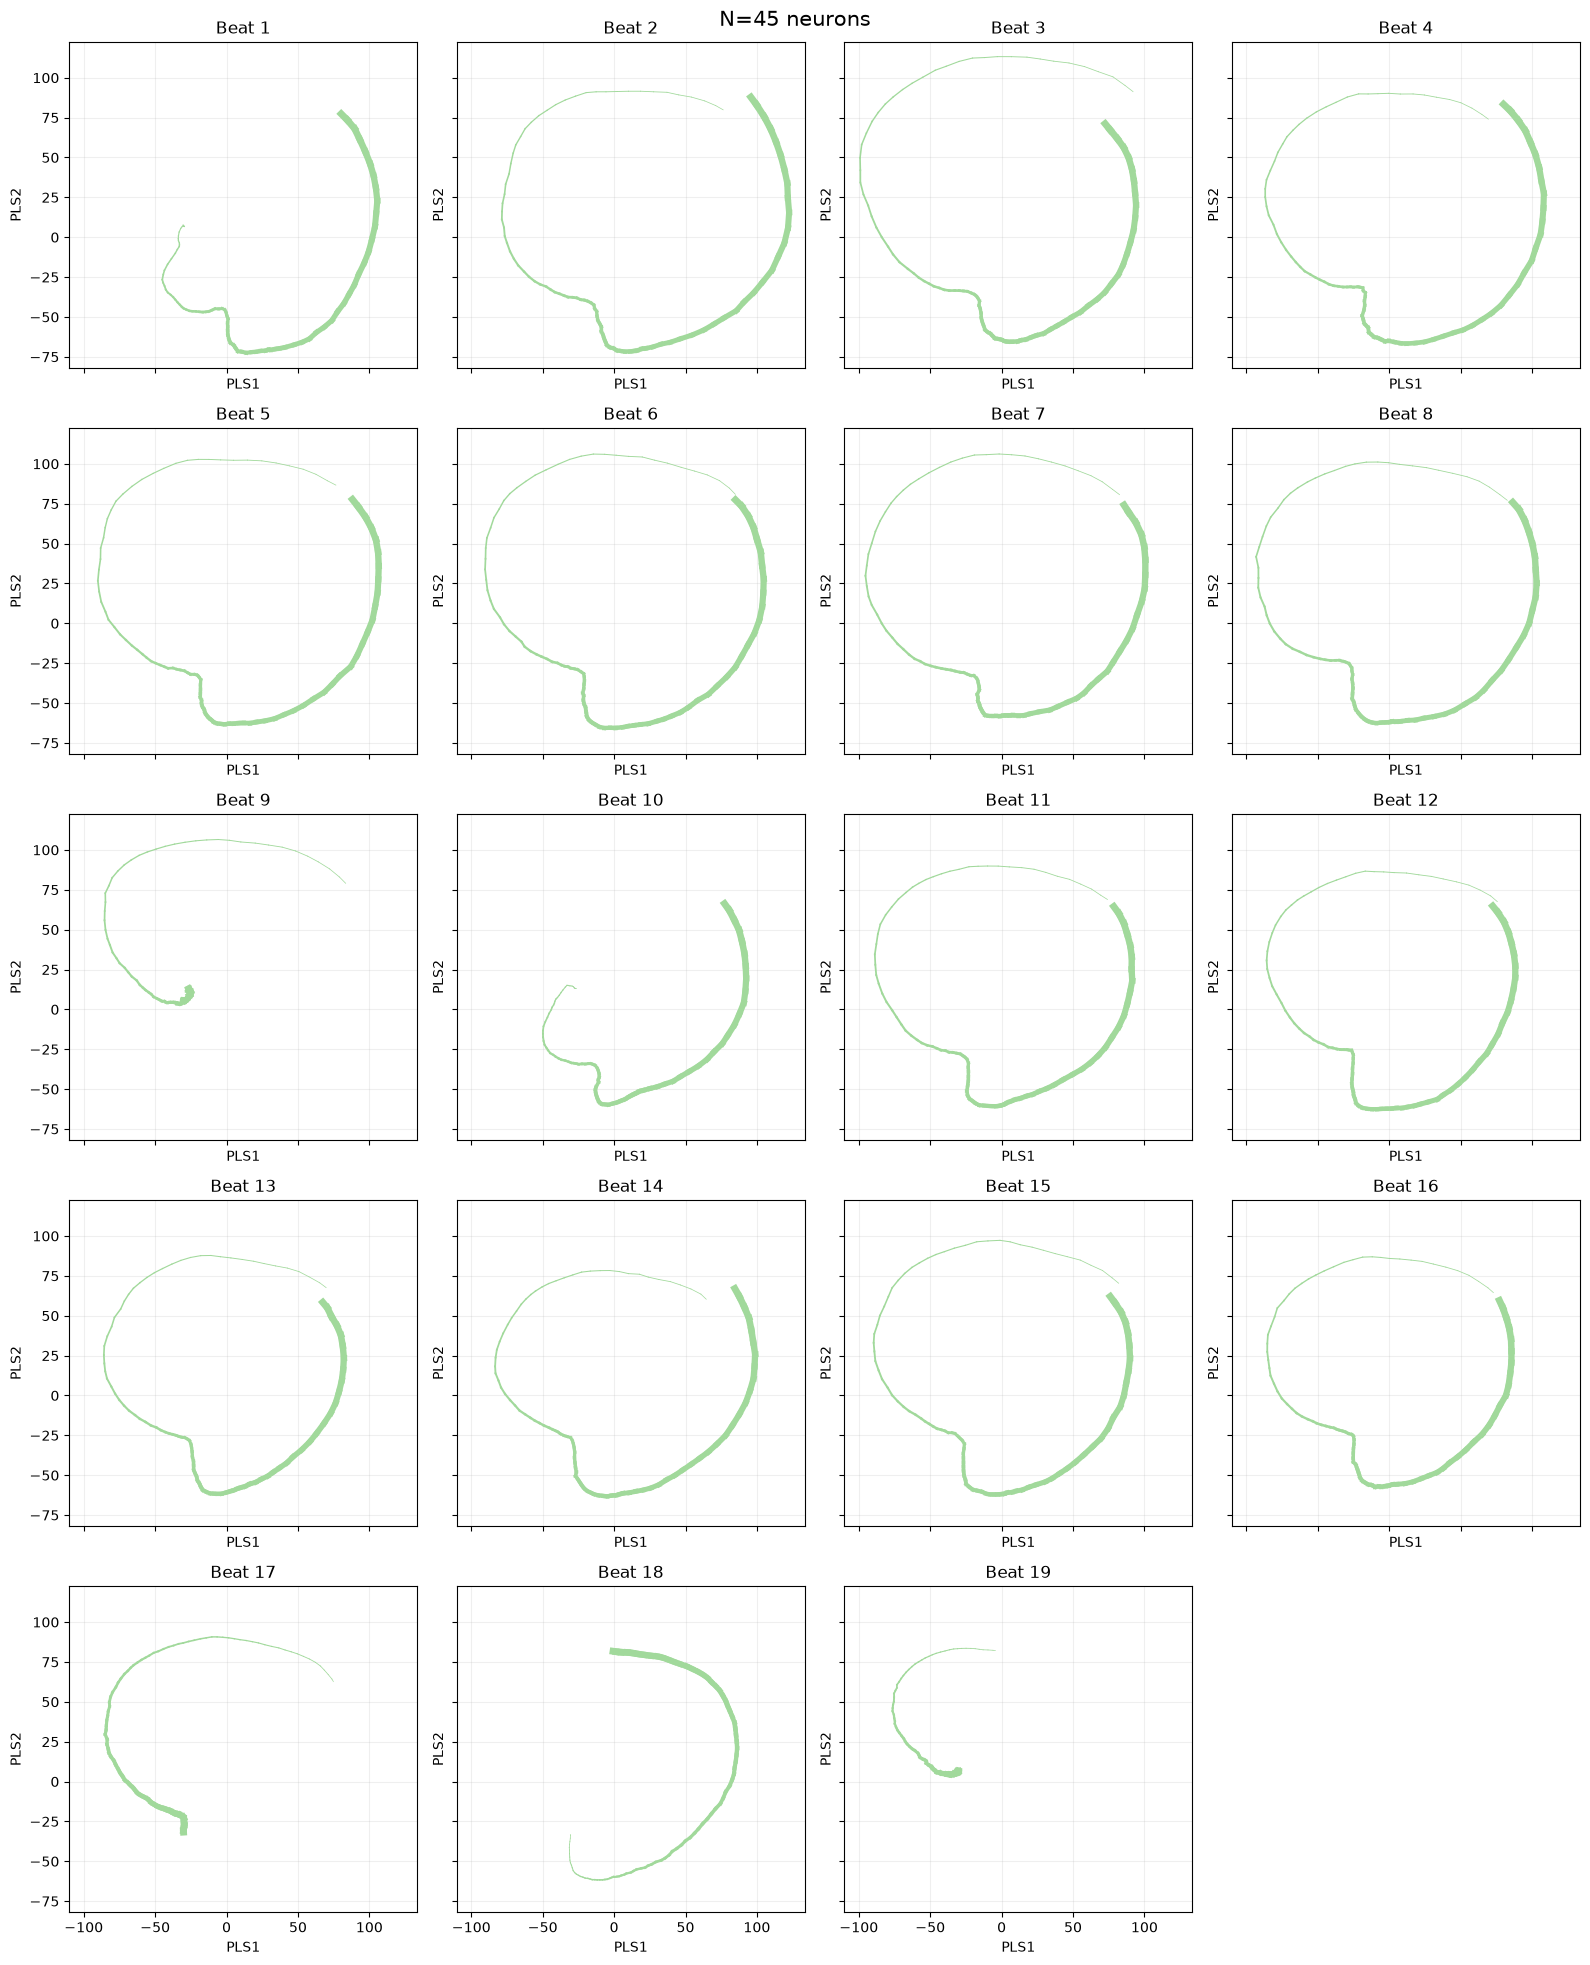

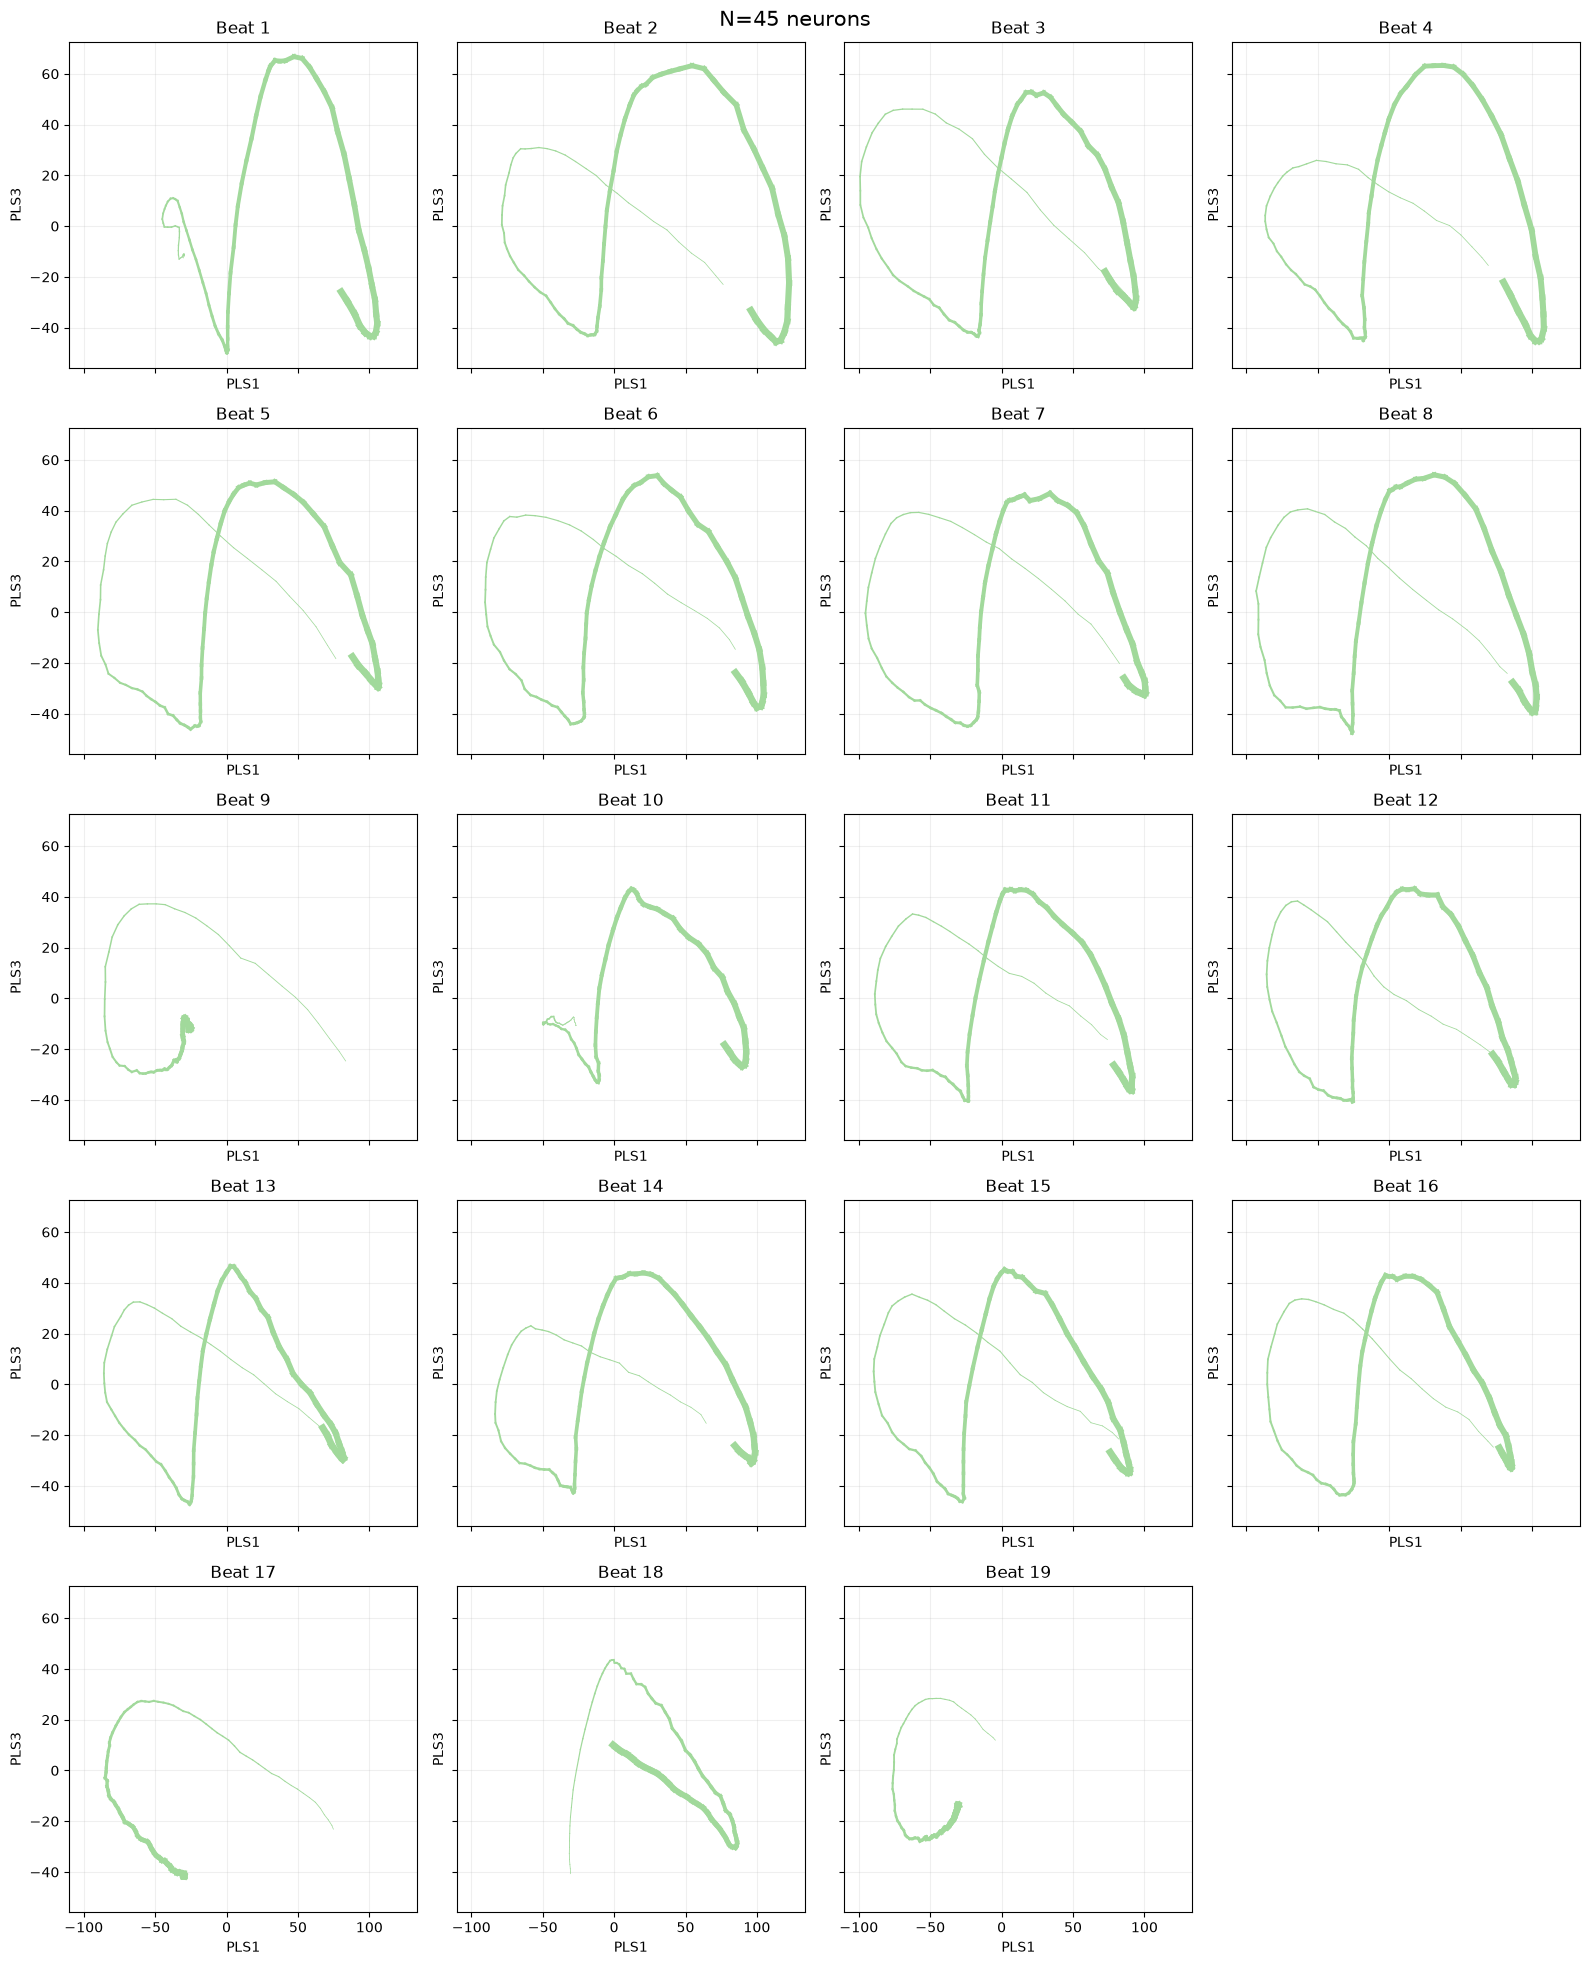

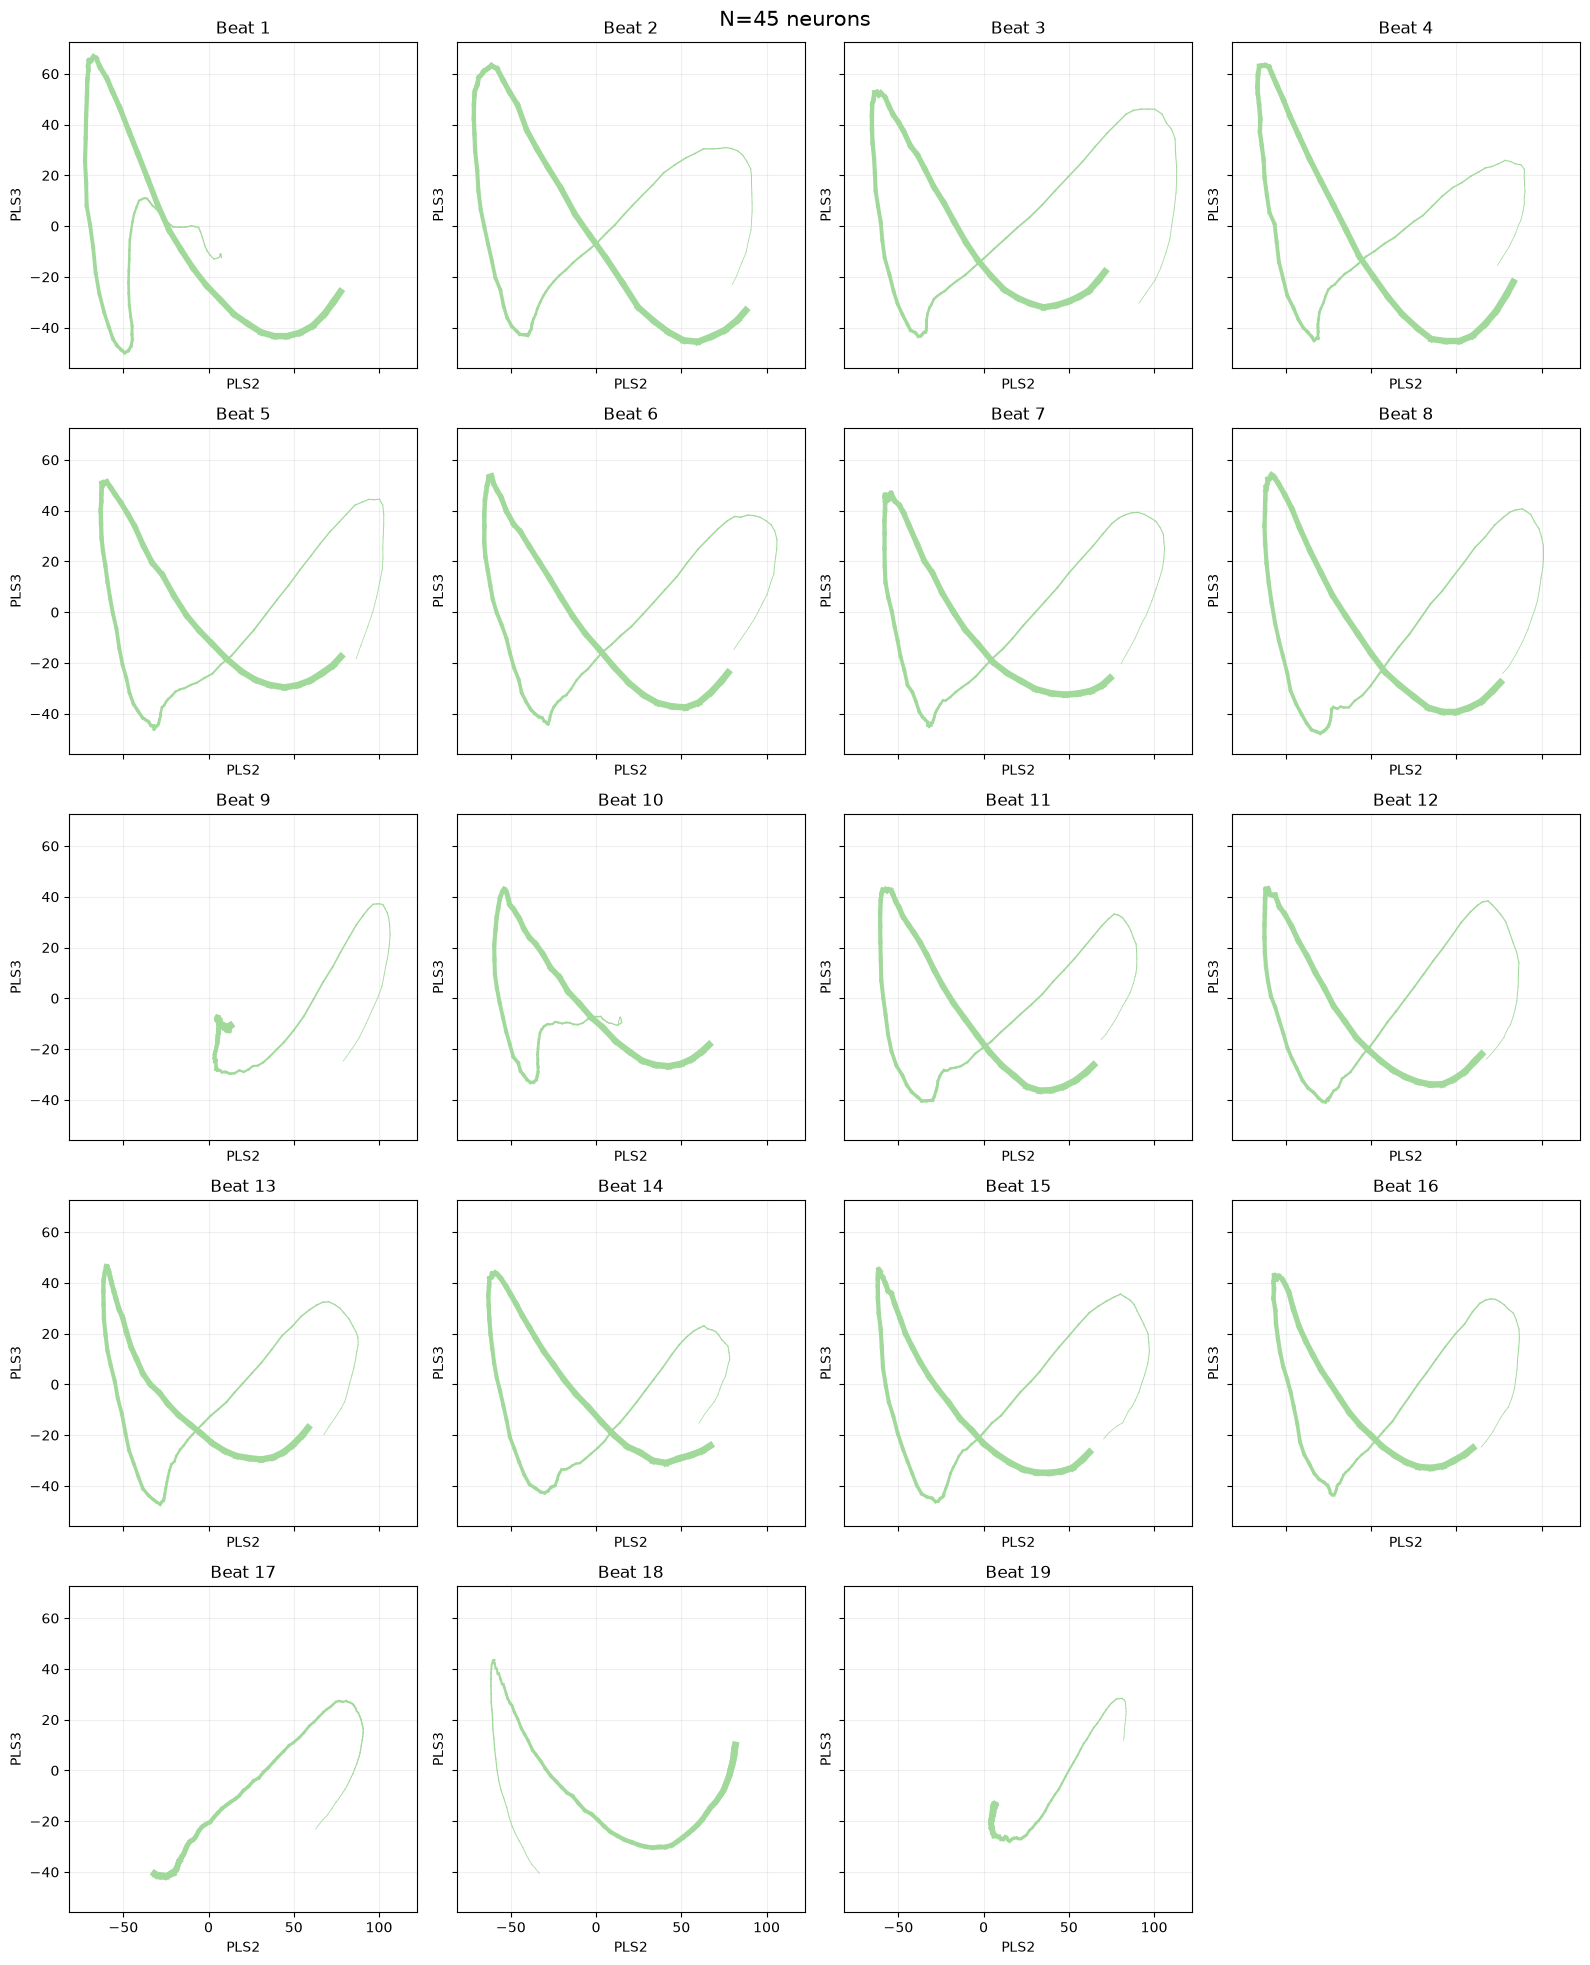

In [8]:
import plotting
beat_traj, beat_time = plotting.plot_beatwise_share(
    trajectories=trajectories,
    response_times=T,
    Y=None,
    beat_times=beat_times,
    colors=colors,
    n_cols=4,
    N=len(top_neurons),
    plot=True
)

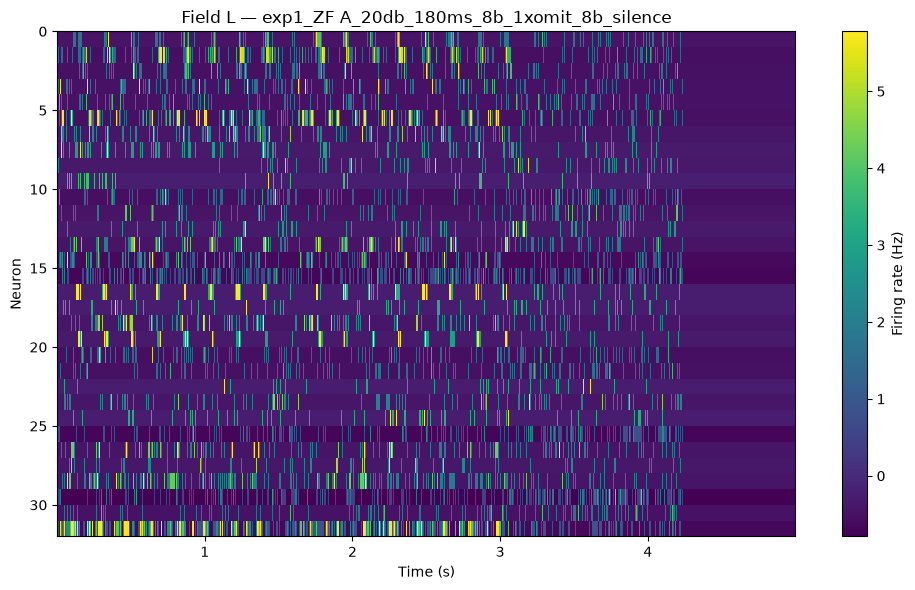

In [9]:
pls.rate(top_neurons, PLS_TRAINING_STIM[0])